# Most popular Genres - Top 20 Genres

In [3]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt


import pyodbc
con = pyodbc.connect(DRIVER = '{ODBC Driver 17 for SQL Server}', SERVER = '.', DATABASE = 'DA07_movieDB', Trusted_Connection = 'Yes', autocommit = 'True')
print('DB Connected successfully')

DB Connected successfully


In [4]:
# 1. Setup your SQLAlchemy database engine
connection_string = (
    "mssql+pyodbc://@./DA07_movieDB?"
    "driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)
engine = create_engine(connection_string)

# 2. Your SQL Query for top 20 genres
query = """
SELECT TOP 20 
    m.genre, 
    COUNT(r.rating_id) AS total_view_count
FROM [dbo].[Movies] m
INNER JOIN [dbo].[ratings] r 
    ON m.movie_id = r.movie_id
GROUP BY 
    m.genre
ORDER BY 
    total_view_count DESC;
"""

C:\Users\SajayN\AppData\Local\Temp\ipykernel_66508\3417937463.py:3: SAWarning: Unrecognized server version info '17.0.1115.1'.  Some SQL Server features may not function properly.
  with engine.connect() as con:


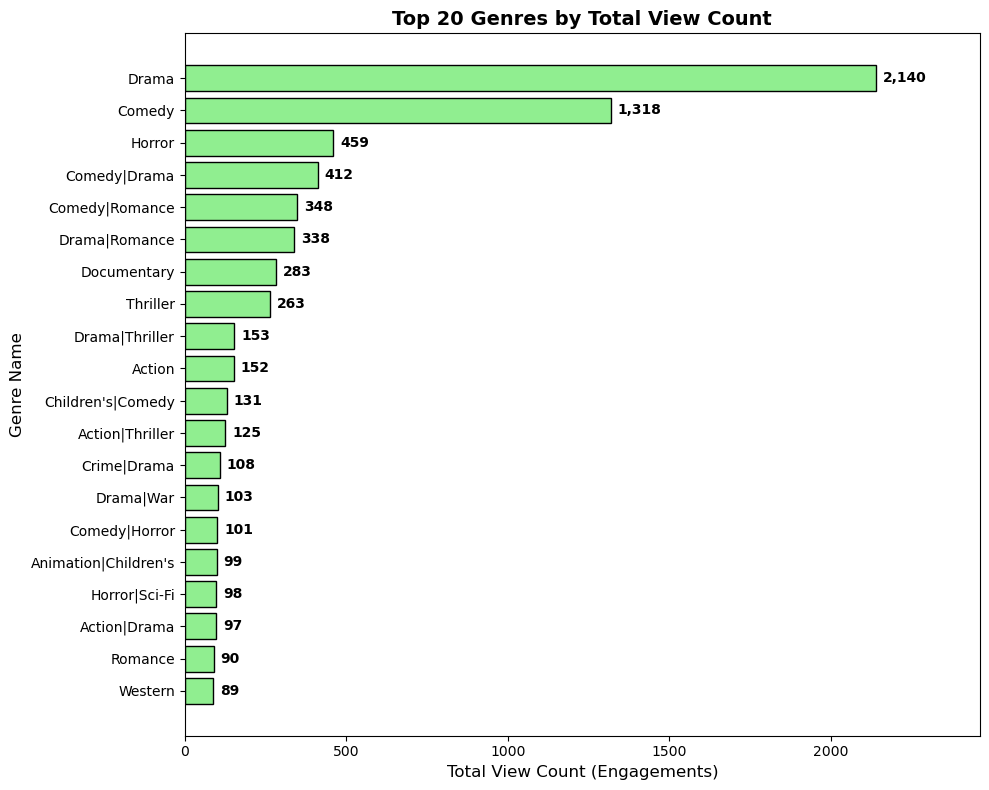

In [5]:
try:
    # 3. Pull the query output into your data frame
    with engine.connect() as con:
        df_top_genres = pd.read_sql(query, con)
    
    # 4. Initialize a clean plot window (making it slightly taller to fit 20 rows)
    plt.figure(figsize=(10, 8))
    
    # 5. Build the horizontal bar chart
    bars = plt.barh(
        df_top_genres['genre'], 
        df_top_genres['total_view_count'], 
        color='lightgreen', 
        edgecolor='black'
    )
    
    # 6. Inject the exact view count numbers onto the bars manually
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + (max(df_top_genres['total_view_count']) * 0.01), # Dynamic text spacing
            bar.get_y() + bar.get_height()/2, 
            f'{int(width):,}', # Formats numbers with commas (e.g., 1,250)
            va='center', 
            ha='left', 
            fontweight='bold',
            fontsize=10
        )
    
    # 7. Customize the chart layout
    plt.gca().invert_yaxis()  # Puts the #1 most-watched genre at the very top
    plt.xlabel('Total View Count (Engagements)', fontsize=12)
    plt.ylabel('Genre Name', fontsize=12)
    plt.title('Top 20 Genres by Total View Count', fontsize=14, fontweight='bold')
    
    # Add whitespace padding to the right edge so numbers don't get clipped
    plt.xlim(0, max(df_top_genres['total_view_count']) * 1.15)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\SajayN\AppData\Local\Temp\ipykernel_66508\681295239.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


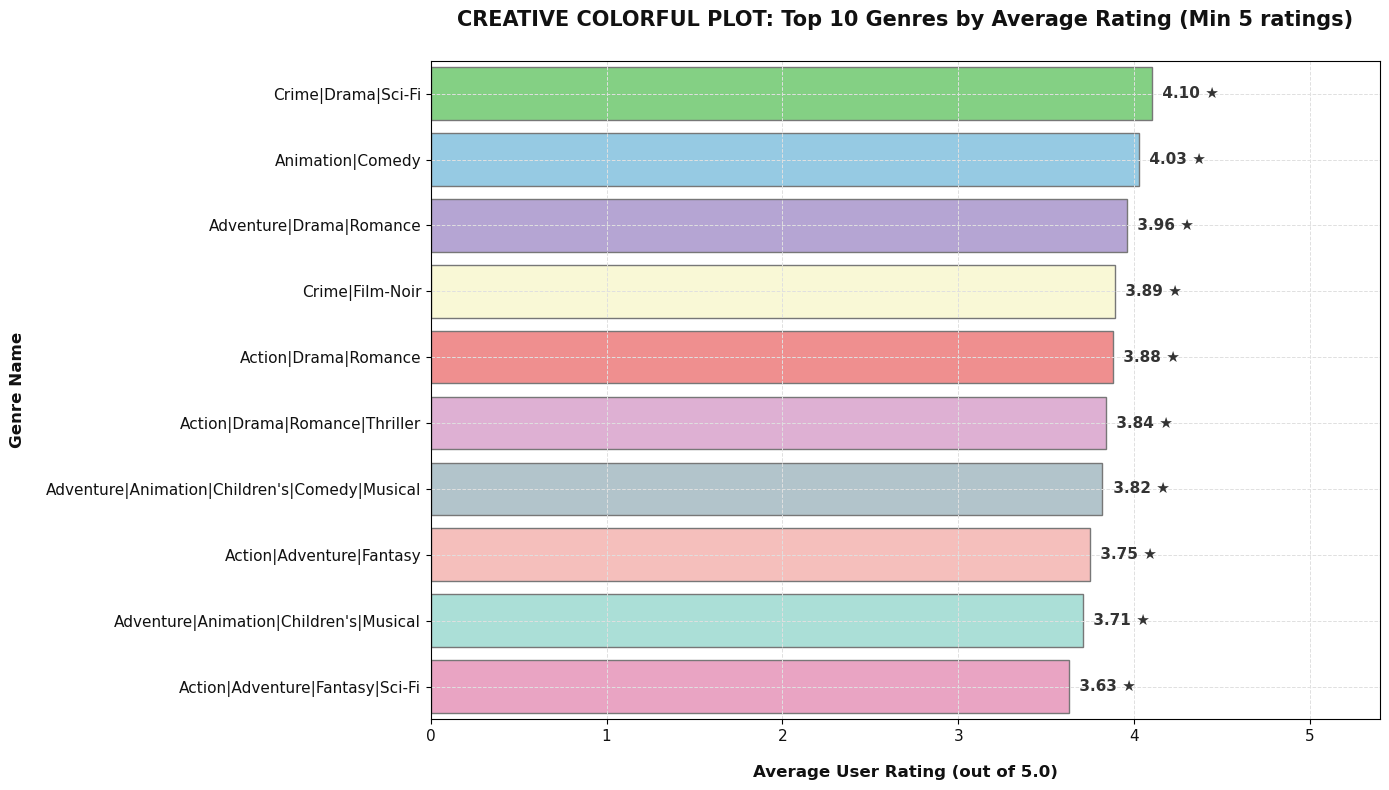

In [7]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to your SQL Server
con = pyodbc.connect(
    DRIVER='{ODBC Driver 17 for SQL Server}', 
    SERVER='.', 
    DATABASE='DA07_movieDB', 
    Trusted_Connection='Yes', 
    autocommit=True
)

# 2. SQL Query: Fetching top 10 genres with minimum 5 ratings requirement
query = """
SELECT TOP 10
    m.genre AS genre_name,
    ROUND(AVG(CAST(r.rating AS FLOAT)), 2) AS average_rating
FROM [dbo].[Movies] m
INNER JOIN [dbo].[ratings] r 
    ON m.movie_id = r.movie_id
GROUP BY 
    m.genre
HAVING 
    COUNT(r.rating) >= 5
ORDER BY 
    average_rating DESC;
"""

df = pd.read_sql(query, con)
con.close()

# 3. Define the lighter, pastel multi-color list for the 10 bars
lighter_creative_colors = [
    '#77DD77',  # 1. Pastel Green
    '#89CFF0',  # 2. Baby Blue
    '#B39DDB',  # 3. Light Purple / Lavender
    '#FFFDD0',  # 4. Cream / Soft Yellow
    '#FF7F7F',  # 5. Light Red / Pastel Coral
    '#E6A8D7',  # 6. Orchid / Soft Violet
    '#AEC6CF',  # 7. Pastel Indigo / Slate Blue
    '#FFB7B2',  # 8. Pastel Pink / Melon
    '#A2E8DD',  # 9. Pale Teal / Mint
    '#F498C2'   # 10. Pastel Magenta
]

bar_colors = lighter_creative_colors[:len(df)]

# 4. Setup the Interface Canvas with a White Background
plt.figure(figsize=(14, 8), facecolor='#FFFFFF') 
ax = plt.gca()
ax.set_facecolor('#FFFFFF')

# Create the horizontal bar plot using our lighter color list
sns.barplot(
    x='average_rating', 
    y='genre_name', 
    data=df, 
    palette=bar_colors,
    hue='genre_name',
    legend=False,
    edgecolor='#777777',  # Soft gray border around bars
    linewidth=1
)

# 5. Cleaned Styling: Special character removed, title ends with (Min 5 ratings)
plt.title('CREATIVE COLORFUL PLOT: Top 10 Genres by Average Rating (Min 5 ratings)', 
          fontsize=15, fontweight='bold', color='#111111', pad=25)

plt.xlabel('Average User Rating (out of 5.0)', fontsize=12, fontweight='bold', color='#111111', labelpad=15)
plt.ylabel('Genre Name', fontsize=12, fontweight='bold', color='#111111', labelpad=15)

# Style tick marks
plt.xticks(color='#111111', fontsize=11)
plt.yticks(color='#111111', fontsize=11)
plt.grid(color='#E0E0E0', linestyle='--', linewidth=0.7) 

# Adjust X-axis ceiling limits for clean text tracking space
plt.xlim(0, 5.4) 

# 6. Clean Bar Data Labels
for i, p in enumerate(ax.patches):
    width = p.get_width()
    rating = df.iloc[i]['average_rating']
    
    label_text = f" {rating:.2f} ★"
    
    ax.text(
        width + 0.03, 
        p.get_y() + p.get_height() / 2, 
        label_text, 
        ha='left', 
        va='center', 
        fontsize=11, 
        fontweight='bold',
        color='#333333'
    )

# Optimize layout constraints
plt.tight_layout()
plt.show()

In [10]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to your SQL Server
con = pyodbc.connect(
    DRIVER='{ODBC Driver 17 for SQL Server}', 
    SERVER='.', 
    DATABASE='DA07_movieDB', 
    Trusted_Connection='Yes', 
    autocommit=True
)

C:\Users\SajayN\AppData\Local\Temp\ipykernel_66508\2520724214.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


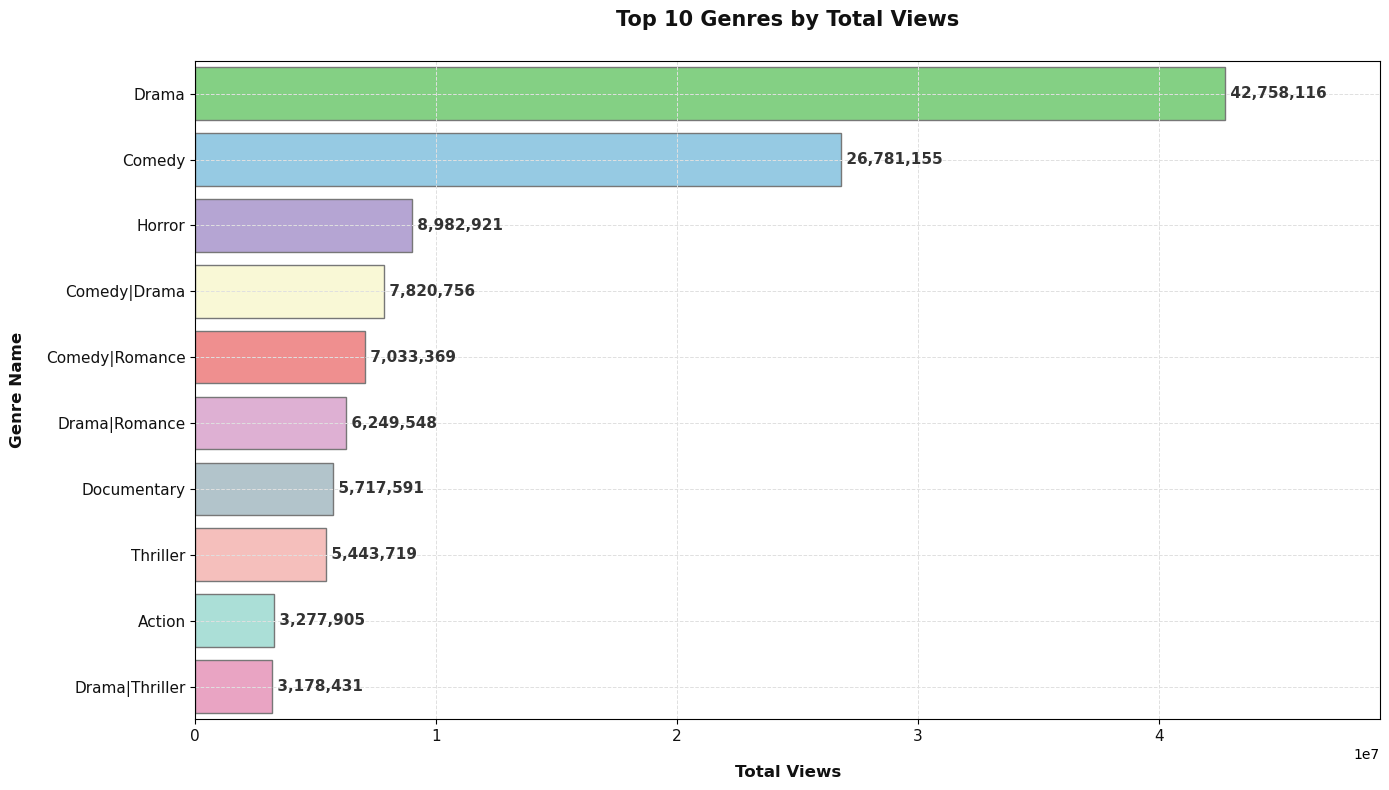

In [12]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to your SQL Server
con = pyodbc.connect(
    DRIVER='{ODBC Driver 17 for SQL Server}', 
    SERVER='.', 
    DATABASE='DA07_movieDB', 
    Trusted_Connection='Yes', 
    autocommit=True
)

# 2. SQL Query: Fetching top 10 genres by total view count
query = """
SELECT TOP 10
    m.genre AS genre_name,
    SUM(m.total_views) AS total_views
FROM [dbo].[Movies] m
GROUP BY 
    m.genre
ORDER BY 
    total_views DESC;
"""

df = pd.read_sql(query, con)
con.close()

# 3. Define the exact same lighter, pastel multi-color list for consistency
lighter_creative_colors = [
    '#77DD77',  # 1. Pastel Green
    '#89CFF0',  # 2. Baby Blue
    '#B39DDB',  # 3. Light Purple / Lavender
    '#FFFDD0',  # 4. Cream / Soft Yellow
    '#FF7F7F',  # 5. Light Red / Pastel Coral
    '#E6A8D7',  # 6. Orchid / Soft Violet
    '#AEC6CF',  # 7. Pastel Indigo / Slate Blue
    '#FFB7B2',  # 8. Pastel Pink / Melon
    '#A2E8DD',  # 9. Pale Teal / Mint
    '#F498C2'   # 10. Pastel Magenta
]

bar_colors = lighter_creative_colors[:len(df)]

# 4. Setup the Interface Canvas with a White Background
plt.figure(figsize=(14, 8), facecolor='#FFFFFF') 
ax = plt.gca()
ax.set_facecolor('#FFFFFF')

# Create the horizontal bar plot using our lighter color list
sns.barplot(
    x='total_views', 
    y='genre_name', 
    data=df, 
    palette=bar_colors,
    hue='genre_name',
    legend=False,
    edgecolor='#777777',  # Soft gray border around bars
    linewidth=1
)

# 5. Fully Cleaned Title: Shows only the direct text description
plt.title('Top 10 Genres by Total Views', 
          fontsize=15, fontweight='bold', color='#111111', pad=25)

plt.xlabel('Total Views', fontsize=12, fontweight='bold', color='#111111', labelpad=15)
plt.ylabel('Genre Name', fontsize=12, fontweight='bold', color='#111111', labelpad=15)

# Style tick marks
plt.xticks(color='#111111', fontsize=11)
plt.yticks(color='#111111', fontsize=11)
plt.grid(color='#E0E0E0', linestyle='--', linewidth=0.7) 

# Dynamically adjust X-axis ceiling limit to give breathing room for the text labels
if not df.empty:
    plt.xlim(0, df['total_views'].max() * 1.15) 

# 6. Clean Bar Data Labels (Formatted with commas)
for i, p in enumerate(ax.patches):
    width = p.get_width()
    views = int(df.iloc[i]['total_views'])
    
    label_text = f" {views:,}"
    
    ax.text(
        width, 
        p.get_y() + p.get_height() / 2, 
        label_text, 
        ha='left', 
        va='center', 
        fontsize=11, 
        fontweight='bold',
        color='#333333'
    )

# Optimize layout constraints
plt.tight_layout()
plt.show()